In [1]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd

#from typing import Any, Dict, List, Union

from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from thesis_project.training.key_word_spotting import CrossEntropyPlusRankLoss, fit_dynamic_model, validate_dynamic_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

BASE_MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
BASE_MODEL_CHECKPOINT = BASE_MODEL_DIR + "best_model.pth"
#BASE_MODEL_HISTORY = np.load(BASE_MODEL_DIR + "history.npy", allow_pickle=True).item()

#DYN_MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-11_16-39-57/"
#DYN_MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-12_11-41-39/"
DYN_MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-07_16-54-00_good/"
DYN_MODEL_CHECKPOINT = DYN_MODEL_DIR + "best_model.pth"
#DYN_MODEL_HISTORY = np.load(DYN_MODEL_DIR + "history.npy", allow_pickle=True).item()

BATCH_SIZE = 64
# Each val_set uses a single noise file - this gives 6 val_sets with different noise types
# but the same underlying audio samples (loaded in the same order with shuffle=False)
NOISE_FILES = [
    "doing_the_dishes.wav",
    "dude_miaowing.wav",
    "exercise_bike.wav",
    "pink_noise.wav",
    "running_tap.wav",
    "white_noise.wav",
]
NUMBER_OF_VAL_SETS = len(NOISE_FILES)
VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    PIN_MEMORY = True
    NUM_WORKERS = 16
    print("Using CUDA")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    PIN_MEMORY = False
    NUM_WORKERS = 0
    print("Using MPS")
else:
    DEVICE = torch.device("cpu")
    PIN_MEMORY = False
    print("Using CPU")


Using MPS


In [2]:
# Model

MAXIMUM_USEFUL_RANK = 64
batch_size = 64

base_model = KWSBase(cfg).to(DEVICE)
router = GRURouter(
    input_dim=base_model.spectrogram_bins, #type: ignore
    fc_hidden_dim=128,
    gru_hidden_dim=64,
    num_gru_layers=1,
    max_rank=MAXIMUM_USEFUL_RANK,
    last_layer_bias_init= 4.0 # to bias towards full rank at start
    ).to(DEVICE)

dyn_model = KWSDynamic(base=base_model, router=router).to(DEVICE)
history_path = DYN_MODEL_CHECKPOINT.replace("best_model.pth", "history.npy")
ckpt = torch.load(DYN_MODEL_CHECKPOINT, map_location=DEVICE)

dyn_model.load_state_dict(ckpt["model_state"])
dyn_model.to(DEVICE)

/Users/christoffer/Documents/Thesis/thesis_project/src/thesis_project/models/components/layers/cpc.py:42: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  U, S, Vt = torch.linalg.svd(W, full_matrices=False)


KWSDynamic(
  (base): KWSBase(
    (spectrogram): SpectrogramBlock(
      (spec): Spectrogram()
      (db): AmplitudeToDB()
      (inv): InverseSpectrogram()
    )
    (frontend): LowRankPointwiseConv1d()
    (backbone): ModuleList(
      (0-2): 3 x ModuleList(
        (0): DDWS_Conv1d(
          (pw_layer_1): LowRankPointwiseConv1d()
          (act1): PReLU(num_parameters=1)
          (dropout1): Dropout(p=0.1, inplace=False)
          (norm1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (ddw_conv): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), groups=128, bias=False)
          (chomp): Chomp()
          (act2): PReLU(num_parameters=1)
          (dropout2): Dropout(p=0.1, inplace=False)
          (norm2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (pw_layer_2): LowRankPointwiseConv1d()
        )
        (1): DDWS_Conv1d(
          (pw_layer_1): LowRankPointwiseConv1d()
      

In [3]:
#Datasets and dataloaders
data_dir = get_data_dir()

# Factory function to create validation loaders on demand (to avoid memory issues)
# Each val_set_id corresponds to a single noise file
def create_val_loader(val_set_id: int):
    """Create a validation loader for the given val_set_id. 
    Each val_set uses a single noise file, so samples are loaded in the same order
    but with different noise types. This allows consistent sample IDs across val_sets."""
    noise_file = NOISE_FILES[val_set_id]
    val_set = SpeechCommandsGoogle(
        root=str(data_dir), 
        subset="validation", 
        download=True, 
        **noise_eval_cfg.model_dump(),
        noise_files=[noise_file],  # Single noise file for this val_set
        seed=789,  # Same seed for all val_sets - consistent sample ordering
    )
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS)
    return val_loader, noise_file

# Note: val_loader is created on demand via create_val_loader(val_set_id) when needed
print(f"Validation loader factory ready. {NUMBER_OF_VAL_SETS} noise files available:")
for i, nf in enumerate(NOISE_FILES):
    print(f"  val_set_id={i}: {nf}")

Validation loader factory ready. 6 noise files available:
  val_set_id=0: doing_the_dishes.wav
  val_set_id=1: dude_miaowing.wav
  val_set_id=2: exercise_bike.wav
  val_set_id=3: pink_noise.wav
  val_set_id=4: running_tap.wav
  val_set_id=5: white_noise.wav


In [4]:
# load normal cross entropy loss for reference
ce_loss_fn = nn.CrossEntropyLoss()

In [5]:
def validate_model(
    model: nn.Module,
    val_loader,
    criterion: nn.Module,
    device: torch.device,
    snr_values=None,
    verbose: bool = True,
    fixed_rank: Optional[int] = None,
    val_set_id: Optional[int] = None,
    noise_file: Optional[str] = None,
    save_embeddings: bool = False,
    is_dynamic: bool = False,
    max_rank: int = 64,
    make_rank_hist: bool = False,
) -> Tuple[
    Dict[Union[int, float, None], Dict[str, Any]],
    List[Dict[str, Any]],
]:
    """
    Unified validation function for both base and dynamic models.
    
    For base models: Evaluates at a fixed_rank across different SNR values.
    For dynamic models: Tracks the dynamically selected rank per sample.
    
    Assumes:
        - val_loader.dataset._set_snr(snr) exists.
        - val_loader yields (waveforms, labels, meta).
        - Base model: model(waveforms, ranks=fixed_rank, return_embedding=True) 
                     returns (logits, embeddings)
        - Dynamic model: model(waveforms) returns (logits, router_output, logits_full_rank)
                        where router_output contains "ranks_normalized" and "ranks_discrete"

    Args:
        model: The model to evaluate (base or dynamic).
        val_loader: DataLoader for validation set.
        criterion: Loss function (CrossEntropyLoss for base, can be CrossEntropyPlusRankLoss for dynamic).
        device: Device to run on.
        snr_values: List of SNR values to evaluate. If None, uses [None].
        verbose: If True, print results per SNR.
        fixed_rank: For base models, the rank to use. Ignored if is_dynamic=True.
        val_set_id: Optional validation set ID for tracking.
        noise_file: Optional noise file name for tracking.
        save_embeddings: If True, save embeddings in per_sample_records (base model only).
        is_dynamic: If True, treat as dynamic model and track router-selected ranks.
        max_rank: Maximum rank for dynamic models (used for histogram and expected rank calculation).
        make_rank_hist: If True and is_dynamic=True, compute rank histogram.

    Returns:
        results: dict {snr: {"loss": float, "acc": float, ...}}
                 For dynamic models, also includes "mean_rank_normalized", "expected_rank",
                 and optionally "rank_histogram".
        
        per_sample_records: list of dicts, one per sample, containing:
            - snr_eval: SNR value used
            - rank: fixed_rank (base) or discrete rank selected by router (dynamic)
            - pred: predicted class
            - target: true class
            - correct: boolean indicating if prediction was correct
            - val_set_id: (if provided)
            - noise_file: (if provided)
            - embedding: (if save_embeddings=True and base model)
            - rank_normalized: (if is_dynamic=True) continuous normalized rank
            - optional metadata fields: label, utterance, noise_type, snr_sample
    """
    if snr_values is None:
        snr_values = [None]

    model.eval()
    results: Dict[Union[int, float, None], Dict[str, Any]] = {}
    per_sample_records: List[Dict[str, Any]] = []

    ds = val_loader.dataset

    def _get_meta_item(meta_val, i):
        """Extract item i from metadata value (handles lists, tensors, etc.)"""
        if isinstance(meta_val, (list, tuple)):
            return meta_val[i]
        if torch.is_tensor(meta_val):
            v = meta_val[i]
            return v.item() if v.numel() == 1 else v.detach().cpu()
        return meta_val

    with torch.no_grad():
        for snr in snr_values:
            ds._set_snr(snr)

            total_loss = 0.0
            total_correct = 0
            total_samples = 0

            # Dynamic-specific accumulators
            total_rnorm = 0.0
            rank_hist = torch.zeros(max_rank, dtype=torch.long) if (is_dynamic and make_rank_hist) else None

            pbar = tqdm(val_loader, desc=f"SNR={snr}", leave=False)

            for waveforms, labels, meta in pbar:
                waveforms = waveforms.to(device)
                labels = labels.to(device)

                # Forward pass differs between base and dynamic models
                if is_dynamic:
                    # Dynamic model returns (logits, router_output, logits_full_rank)
                    logits, router_output, _ = model(waveforms)
                    r_normalized = router_output["ranks_normalized"]  # continuous [0,1]
                    r_cont = router_output["ranks_cont"]               # continuous [1..max_rank]
                    
                    # Compute loss (may be CrossEntropyPlusRankLoss or just CrossEntropyLoss)
                    if isinstance(criterion, CrossEntropyPlusRankLoss):
                        loss_out = criterion(logits, labels, r_normalized)
                        loss = loss_out.loss
                    else:
                        loss = criterion(logits, labels)
                    
                    embeddings = None  # Dynamic model doesn't return embeddings in this setup
                else:
                    # Base model returns (logits, embeddings)
                    logits, embeddings = model(waveforms, ranks=fixed_rank, return_embedding=True)
                    loss = criterion(logits, labels)
                    r_normalized = None
                    r_cont = None

                batch_size = labels.size(0)
                total_samples += batch_size
                total_loss += loss.item() * batch_size

                preds = logits.argmax(dim=1)
                correct_mask = preds == labels
                total_correct += int(correct_mask.sum().item())

                # Prepare CPU arrays for per-sample records
                preds_cpu = preds.detach().cpu().tolist()
                labels_cpu = labels.detach().cpu().tolist()
                correct_cpu = correct_mask.detach().cpu().tolist()

                if is_dynamic:
                    r_normalized_cpu = r_normalized.detach().cpu().tolist()
                    r_cont_cpu = r_cont.detach().cpu().tolist()
                    
                    # Accumulate for mean rank
                    total_rnorm += r_normalized.sum().item()
                    
                    # Accumulate histogram (using rounded values for histogram bins)
                    if make_rank_hist:
                        r_discrete = torch.round(r_cont).clamp(1, max_rank).long()
                        for r in r_discrete.detach().cpu().tolist():
                            rank_hist[r - 1] += 1  # r is in [1..max_rank], index is [0..max_rank-1]

                # Build per-sample records
                for i in range(batch_size):
                    rec = {
                        "snr_eval": snr,
                        "pred": int(preds_cpu[i]),
                        "target": int(labels_cpu[i]),
                        "correct": bool(correct_cpu[i]),
                    }

                    if is_dynamic:
                        rec["rank"] = float(r_cont_cpu[i])  # continuous rank in [1..max_rank]
                        rec["rank_normalized"] = float(r_normalized_cpu[i])
                    else:
                        rec["rank"] = fixed_rank

                    if save_embeddings and embeddings is not None:
                        rec["embedding"] = embeddings[i].detach().cpu().numpy()

                    if val_set_id is not None:
                        rec["val_set_id"] = val_set_id
                    
                    if noise_file is not None:
                        rec["noise_file"] = noise_file

                    # Extract metadata if available
                    if isinstance(meta, dict):
                        for k in ["label", "utterance", "noise_type"]:
                            if k in meta:
                                rec[k] = _get_meta_item(meta[k], i)
                        if "snr" in meta:
                            rec["snr_sample"] = _get_meta_item(meta["snr"], i)

                    per_sample_records.append(rec)

                # Update progress bar
                pbar_dict = {
                    "loss": f"{loss.item():.4f}",
                    "acc": f"{100 * total_correct / total_samples:.2f}%",
                }
                if is_dynamic:
                    running_mean_rnorm = total_rnorm / max(total_samples, 1)
                    running_expected_rank = 1.0 + running_mean_rnorm * (max_rank - 1)
                    pbar_dict["exp_r"] = f"{running_expected_rank:.1f}"
                
                pbar.set_postfix(pbar_dict)

            # Compute epoch aggregates
            avg_loss = total_loss / max(total_samples, 1)
            avg_acc = 100.0 * total_correct / max(total_samples, 1)
            
            snr_result = {"loss": avg_loss, "acc": avg_acc}

            if is_dynamic:
                mean_rnorm = total_rnorm / max(total_samples, 1)
                expected_rank = 1.0 + mean_rnorm * (max_rank - 1)
                snr_result["mean_rank_normalized"] = mean_rnorm
                snr_result["expected_rank"] = expected_rank
                
                if make_rank_hist:
                    snr_result["rank_histogram"] = rank_hist.tolist()

            results[snr] = snr_result

            if verbose:
                if is_dynamic:
                    print(f"SNR={snr}: loss={avg_loss:.4f}, acc={avg_acc:.2f}%, expected_rank={expected_rank:.2f}")
                else:
                    print(f"SNR={snr}: loss={avg_loss:.4f}, acc={avg_acc:.2f}%")

    return results, per_sample_records

In [6]:
maximum_useful_rank = 64
target_rank = 16
target_rank_normalized = (target_rank - 1) / (maximum_useful_rank - 1)

# Collect results across all validation sets
all_results = {}
all_sample_records = []

for val_set_id in range(NUMBER_OF_VAL_SETS):
    val_loader, noise_file = create_val_loader(val_set_id)
    print(f"Validating on val_set_id={val_set_id} with noise file: {noise_file}")
    
    # Using the unified validate_model function with is_dynamic=True
    validation_results, per_sample_records = validate_model(
        model=dyn_model,
        val_loader=val_loader,
        criterion=ce_loss_fn,
        device=DEVICE,
        snr_values=VAL_SNR_VALUES,
        val_set_id=val_set_id,
        noise_file=noise_file,
        is_dynamic=True,
        max_rank=maximum_useful_rank,
        make_rank_hist=True,
        verbose=True,
    )
    
    all_results[val_set_id] = validation_results
    all_sample_records.extend(per_sample_records)
    
    # break  # REMOVE THIS BREAK TO RUN ALL VALIDATION SETS

Adding noise: 100%|██████████| 4515/4515 [00:17<00:00, 253.52sample/s]


Validating on val_set_id=0 with noise file: doing_the_dishes.wav


SNR=-5: loss=1.1445, acc=64.92%, expected_rank=19.28


SNR=0: loss=0.6706, acc=78.85%, expected_rank=18.45


SNR=5: loss=0.4709, acc=85.60%, expected_rank=18.08


...

SNR=0: loss=0.4367, acc=86.29%, expected_rank=19.78


SNR=5: loss=0.3565, acc=88.93%, expected_rank=18.39


SNR=10: loss=0.3173, acc=90.52%, expected_rank=17.83


SNR=15: loss=0.2973, acc=91.34%, expected_rank=17.77


SNR=inf: loss=0.2502, acc=92.71%, expected_rank=17.27


In [7]:
# Create DataFrame from per-sample records
df_dyn = pd.DataFrame(all_sample_records)

# Get length of a single validation set (samples per SNR)
# Since samples are in the same order for all noise files, we can compute length from any group
len_single_val_set = df_dyn.groupby(['val_set_id', 'snr_eval']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")

# Assign an ID to each sample based on its position within each snr_eval group
# This ID is consistent across all val_set_id (noise files) since samples are loaded in same order
df_dyn['id'] = df_dyn.groupby(['snr_eval']).cumcount() % len_single_val_set

# Verify: each (id, snr_eval) should have exactly NUMBER_OF_VAL_SETS rows (one per noise file)
print(f"Unique noise files: {df_dyn['noise_file'].unique().tolist()}")
print(f"Rows per (id, snr_eval): {df_dyn.groupby(['id', 'snr_eval']).size().iloc[0]} (expected: {NUMBER_OF_VAL_SETS})")

# Display DataFrame info
print(f"\nDataFrame shape: {df_dyn.shape}")
print(f"Columns: {df_dyn.columns.tolist()}")
print(f"\nFirst few rows:")

# Save dynamic model results to CSV
dyn_results_path = DYN_MODEL_DIR + "per_sample_results_dynamic.csv"
df_dyn.to_csv(dyn_results_path, index=False)
print(f"\nSaved dynamic model per-sample results to: {dyn_results_path}")

df_dyn.head()

Length of single validation set: 4515
Unique noise files: ['doing_the_dishes.wav', 'dude_miaowing.wav', 'exercise_bike.wav', 'pink_noise.wav', 'running_tap.wav', 'white_noise.wav']
Rows per (id, snr_eval): 6 (expected: 6)

DataFrame shape: (162540, 13)
Columns: ['snr_eval', 'pred', 'target', 'correct', 'rank', 'rank_normalized', 'val_set_id', 'noise_file', 'label', 'utterance', 'noise_type', 'snr_sample', 'id']

First few rows:

Saved dynamic model per-sample results to: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-07_16-54-00_good/per_sample_results_dynamic.csv

Saved dynamic model per-sample results to: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-07_16-54-00_good/per_sample_results_dynamic.csv


,snr_eval,pred,target,correct,rank,rank_normalized,val_set_id,noise_file,label,utterance,noise_type,snr_sample,id
0,-5.0,0,0,True,18.855190,0.283416,0,doing_the_dishes.wav,down,down,doing_the_dishes,-5.0,0
1,-5.0,5,0,False,20.743570,0.313390,0,doing_the_dishes.wav,down,down,doing_the_dishes,-5.0,1
2,-5.0,3,0,False,16.895376,0.252308,0,doing_the_dishes.wav,down,down,doing_the_dishes,-5.0,2
3,-5.0,0,0,True,22.140547,0.335564,0,doing_the_dishes.wav,down,down,doing_the_dishes,-5.0,3
4,-5.0,0,0,True,18.010519,0.270008,0,doing_the_dishes.wav,down,down,doing_the_dishes,-5.0,4


In [8]:
# LOAD BASE MODEL STATS:
# Load per-sample results from CSV files
all_per_sample_dfs = {}
comb_names = ["comb_1"]  # Add other combination names if needed
for comb_name in comb_names:
    df = pd.read_csv(BASE_MODEL_DIR + f"per_sample_results_{comb_name}_golden.csv")
    all_per_sample_dfs[comb_name] = df

print(f"\nLoaded per-sample results from {BASE_MODEL_DIR}:")

df_base = all_per_sample_dfs["comb_1"]
# get the length of a single validation set (samples per snr_eval, rank combo)
# Since samples are in the same order for all noise files, we can compute length from any group
len_single_val_set = df_base.groupby(['val_set_id', 'snr_eval', 'rank']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")

# Assigning an ID to each sample based on its position within each (snr_eval, rank) group
# This ID is consistent across all val_set_id (noise files) since samples are loaded in same order
df_base['id'] = df_base.groupby(['snr_eval', 'rank']).cumcount() % len_single_val_set

# Add model name column
df_base['model_name'] = 'base'

# Verify: each (id, snr_eval, rank) should have exactly NUMBER_OF_VAL_SETS rows (one per noise file)
print(f"Unique noise files: {df_base['noise_file'].unique().tolist()}")
print(f"Rows per (id, snr_eval, rank): {df_base.groupby(['id', 'snr_eval', 'rank']).size().iloc[0]} (expected: {len(df_base['val_set_id'].unique())})")


Loaded per-sample results from /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/:
Length of single validation set: 4515
Length of single validation set: 4515
Unique noise files: ['doing_the_dishes.wav', 'dude_miaowing.wav', 'exercise_bike.wav', 'pink_noise.wav', 'running_tap.wav', 'white_noise.wav']
Unique noise files: ['doing_the_dishes.wav', 'dude_miaowing.wav', 'exercise_bike.wav', 'pink_noise.wav', 'running_tap.wav', 'white_noise.wav']
Rows per (id, snr_eval, rank): 6 (expected: 6)
Rows per (id, snr_eval, rank): 6 (expected: 6)


In [9]:
# LOAD DYNAMIC MODEL RESULTS FROM MULTIPLE DIRECTORIES
# Specify the directories containing dynamic model results
DYN_MODEL_DIRS = [
    "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-11_16-39-57/",
    # Add more directories here as needed
    "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-12_11-41-39/"
]
# add the dynamic model directory used above if not already included
if DYN_MODEL_DIR not in DYN_MODEL_DIRS:
    DYN_MODEL_DIRS.append(DYN_MODEL_DIR)

# Load all dynamic model DataFrames
dyn_dfs = []

for dyn_dir in DYN_MODEL_DIRS:
    csv_path = dyn_dir + "per_sample_results_dynamic.csv"
    try:
        df = pd.read_csv(csv_path)
        
        # Extract a readable name from the directory (e.g., the timestamp folder name)
        model_name = dyn_dir.rstrip('/').split('/')[-1]
        df['model_name'] = model_name
        
        dyn_dfs.append(df)
        print(f"Loaded dynamic model results from: {model_name}")
    except FileNotFoundError:
        print(f"Warning: Could not find {csv_path}")

# Combine all dynamic model DataFrames
if dyn_dfs:
    df_dyn_combined = pd.concat(dyn_dfs, ignore_index=True)
    print(f"\nCombined dynamic model DataFrame shape: {df_dyn_combined.shape}")
    print(f"Models included: {df_dyn_combined['model_name'].unique().tolist()}")
else:
    print("No dynamic model results loaded!")
    df_dyn_combined = None

Loaded dynamic model results from: 2026-01-11_16-39-57
Loaded dynamic model results from: 2026-01-12_11-41-39
Loaded dynamic model results from: 2026-01-07_16-54-00_good

Combined dynamic model DataFrame shape: (487620, 14)
Models included: ['2026-01-11_16-39-57', '2026-01-12_11-41-39', '2026-01-07_16-54-00_good']
Loaded dynamic model results from: 2026-01-07_16-54-00_good

Combined dynamic model DataFrame shape: (487620, 14)
Models included: ['2026-01-11_16-39-57', '2026-01-12_11-41-39', '2026-01-07_16-54-00_good']



SNR=-5.0:
  2026-01-11_16-39-57: rank=19.94, acc=74.26%
  2026-01-12_11-41-39: rank=30.78, acc=77.11%
  2026-01-07_16-54-00_good: rank=19.99, acc=75.49%
  Base @ rank=20: acc=73.78%
  Base @ rank=19: acc=73.60%
  2026-01-12_11-41-39: rank=30.78, acc=77.11%
  2026-01-07_16-54-00_good: rank=19.99, acc=75.49%
  Base @ rank=20: acc=73.78%
  Base @ rank=19: acc=73.60%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/1043201719.py:74: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


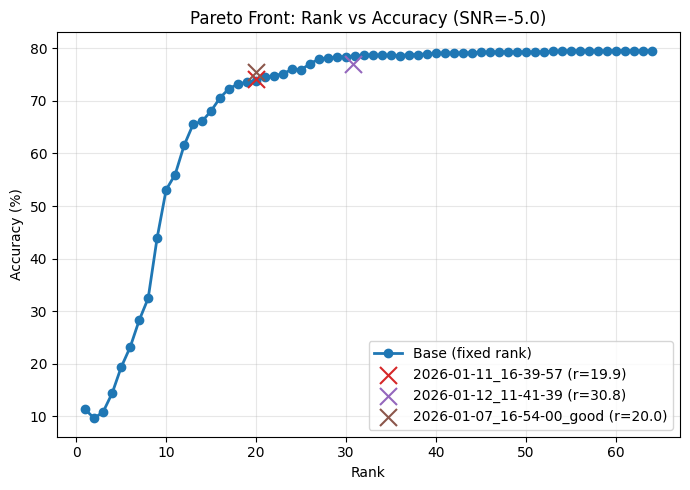


SNR=0.0:
  2026-01-11_16-39-57: rank=18.83, acc=82.73%
  2026-01-12_11-41-39: rank=27.33, acc=84.99%
  2026-01-07_16-54-00_good: rank=18.77, acc=83.85%
  Base @ rank=19: acc=82.74%
  Base @ rank=18: acc=82.36%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/1043201719.py:74: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


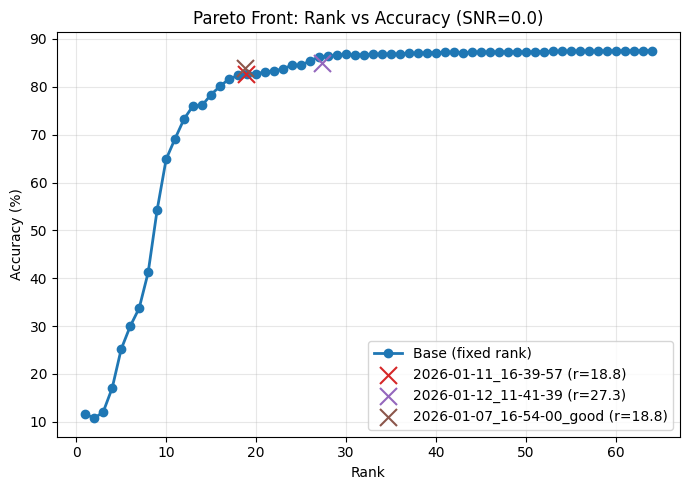


SNR=5.0:
  2026-01-11_16-39-57: rank=18.02, acc=86.84%
  2026-01-12_11-41-39: rank=24.89, acc=88.47%
  2026-01-07_16-54-00_good: rank=17.86, acc=87.84%
  Base @ rank=18: acc=86.98%
  Base @ rank=19: acc=87.22%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/1043201719.py:74: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


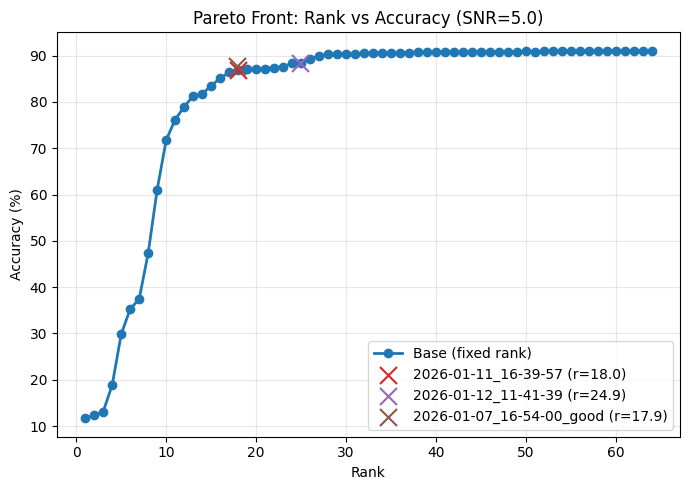


SNR=10.0:
  2026-01-11_16-39-57: rank=17.86, acc=89.25%
  2026-01-12_11-41-39: rank=23.36, acc=90.28%
  2026-01-07_16-54-00_good: rank=17.52, acc=89.85%
  Base @ rank=18: acc=89.35%
  Base @ rank=17: acc=88.79%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/1043201719.py:74: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


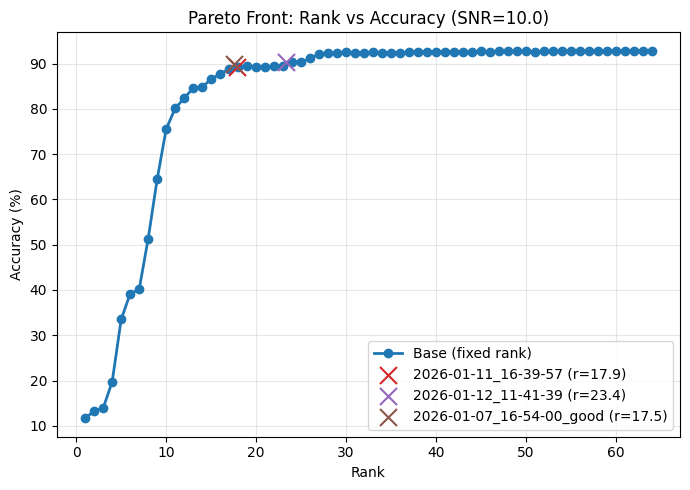


SNR=15.0:
  2026-01-11_16-39-57: rank=18.12, acc=90.73%
  2026-01-12_11-41-39: rank=22.55, acc=91.13%
  2026-01-07_16-54-00_good: rank=17.48, acc=90.94%
  Base @ rank=18: acc=90.37%
  Base @ rank=19: acc=90.57%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/1043201719.py:74: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


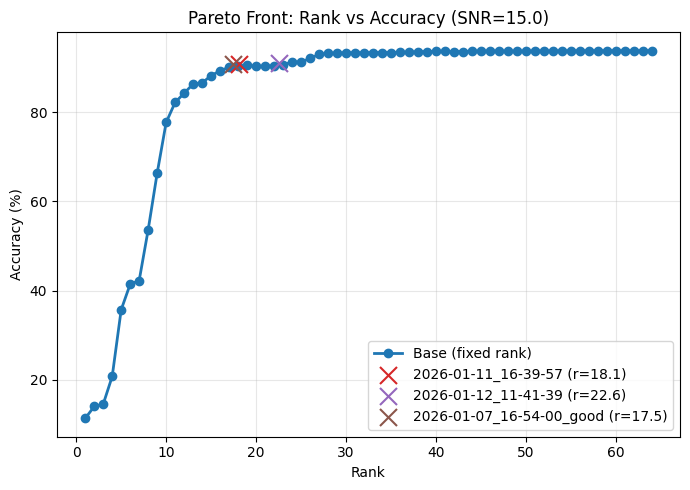


SNR=inf:
  2026-01-11_16-39-57: rank=18.31, acc=92.16%
  2026-01-12_11-41-39: rank=23.61, acc=92.66%
  2026-01-07_16-54-00_good: rank=17.20, acc=92.19%
  Base @ rank=18: acc=91.41%
  Base @ rank=19: acc=91.53%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/1043201719.py:74: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


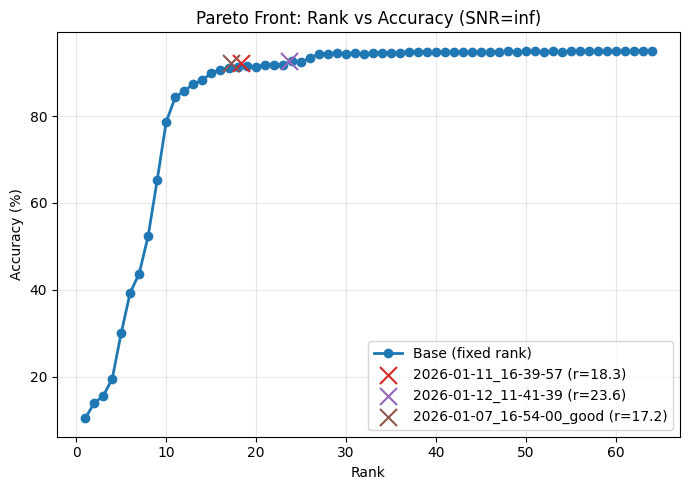

In [10]:
import matplotlib.pyplot as plt

def plot_pareto_front_per_snr(
    df_base: pd.DataFrame,
    df_dyn: pd.DataFrame,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    model_name_col: str = "model_name",
    figsize: tuple = (7, 5),
    marker_base: str = "o-",
    marker_dyn: str = "x",
    color_base: str = "C0",
    dyn_colors: list = None,
):
    """
    Plot Pareto fronts: rank vs accuracy for each SNR value.
    
    Base model: shown as a curve with multiple rank points (averaged over noise files)
    Dynamic models: shown as points (mean rank, mean accuracy) - supports multiple models
    
    Args:
        df_base: DataFrame with base model results (fixed ranks)
        df_dyn: DataFrame with dynamic model results (continuous ranks), can contain multiple models
        dyn_colors: List of colors for dynamic models. If None, uses default color cycle.
    """
    
    if dyn_colors is None:
        dyn_colors = ['C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
    
    # Get unique SNR values
    snrs = sorted(df_base[snr_col].unique())
    
    # Get unique dynamic model names
    dyn_model_names = df_dyn[model_name_col].unique()
    
    for snr in snrs:
        # --- BASE MODEL: aggregate over noise files for each rank ---
        base_snr = df_base[df_base[snr_col] == snr]
        base_agg = (
            base_snr.groupby(rank_col)[correct_col]
            .mean()
            .mul(100)
            .reset_index()
            .rename(columns={correct_col: "acc"})
            .sort_values(rank_col)
        )
        
        # --- PLOT ---
        plt.figure(figsize=figsize)
        
        # Base model curve
        plt.plot(
            base_agg[rank_col],
            base_agg["acc"],
            marker_base,
            label="Base (fixed rank)",
            color=color_base,
            linewidth=2,
            markersize=6,
        )
        
        # --- DYNAMIC MODELS: one point per model ---
        print(f"\nSNR={snr}:")
        
        for idx, model_name in enumerate(dyn_model_names):
            dyn_snr = df_dyn[(df_dyn[snr_col] == snr) & (df_dyn[model_name_col] == model_name)]
            dyn_mean_rank = dyn_snr[rank_col].mean()
            dyn_mean_acc = dyn_snr[correct_col].mean() * 100
            
            color = dyn_colors[idx % len(dyn_colors)]
            
            plt.scatter(
                [dyn_mean_rank],
                [dyn_mean_acc],
                s=150,
                marker=marker_dyn,
                color=color,
                label=f"{model_name} (r={dyn_mean_rank:.1f})",
                edgecolors="black",
                linewidths=1.5,
                zorder=5,
            )
            
            print(f"  {model_name}: rank={dyn_mean_rank:.2f}, acc={dyn_mean_acc:.2f}%")
        
        # Find the two closest base model ranks to first dynamic model
        if len(dyn_model_names) > 0:
            first_dyn_snr = df_dyn[(df_dyn[snr_col] == snr) & (df_dyn[model_name_col] == dyn_model_names[0])]
            first_dyn_rank = first_dyn_snr[rank_col].mean()
            
            base_agg['rank_diff'] = abs(base_agg[rank_col] - first_dyn_rank)
            closest_two = base_agg.nsmallest(2, 'rank_diff')
            
            for _, row in closest_two.iterrows():
                print(f"  Base @ rank={int(row[rank_col])}: acc={row['acc']:.2f}%")
        
        plt.xlabel("Rank")
        plt.ylabel("Accuracy (%)")
        plt.title(f"Pareto Front: Rank vs Accuracy (SNR={snr})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# Call the function
if df_dyn_combined is not None:
    plot_pareto_front_per_snr(df_base, df_dyn_combined)


Label: down (target=0)
  2026-01-11_16-39-57: rank=18.10, acc=89.54%
  2026-01-12_11-41-39: rank=24.93, acc=90.42%
  2026-01-07_16-54-00_good: rank=17.95, acc=89.10%
  Base @ rank=18: acc=90.08%
  Base @ rank=19: acc=90.68%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


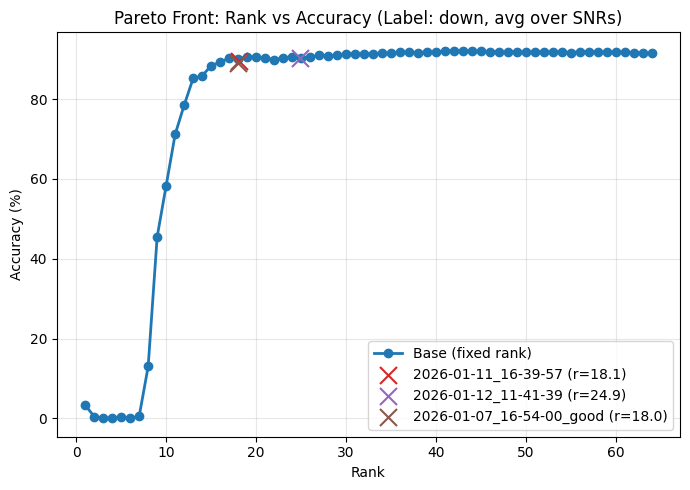


Label: go (target=1)
  2026-01-11_16-39-57: rank=18.25, acc=74.76%
  2026-01-12_11-41-39: rank=25.13, acc=83.99%
  2026-01-07_16-54-00_good: rank=18.08, acc=81.83%
  Base @ rank=18: acc=76.37%
  Base @ rank=19: acc=80.22%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


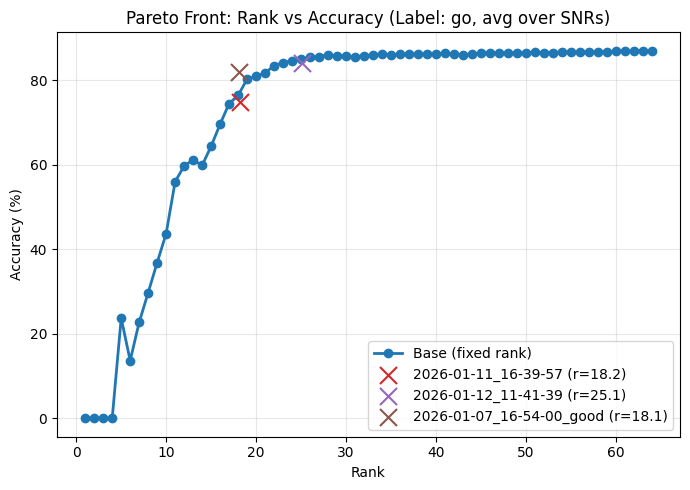


Label: left (target=2)
  2026-01-11_16-39-57: rank=18.13, acc=90.36%
  2026-01-12_11-41-39: rank=24.62, acc=91.19%
  2026-01-07_16-54-00_good: rank=17.91, acc=90.43%
  Base @ rank=18: acc=90.66%
  Base @ rank=19: acc=90.48%

  2026-01-11_16-39-57: rank=18.13, acc=90.36%
  2026-01-12_11-41-39: rank=24.62, acc=91.19%
  2026-01-07_16-54-00_good: rank=17.91, acc=90.43%
  Base @ rank=18: acc=90.66%
  Base @ rank=19: acc=90.48%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


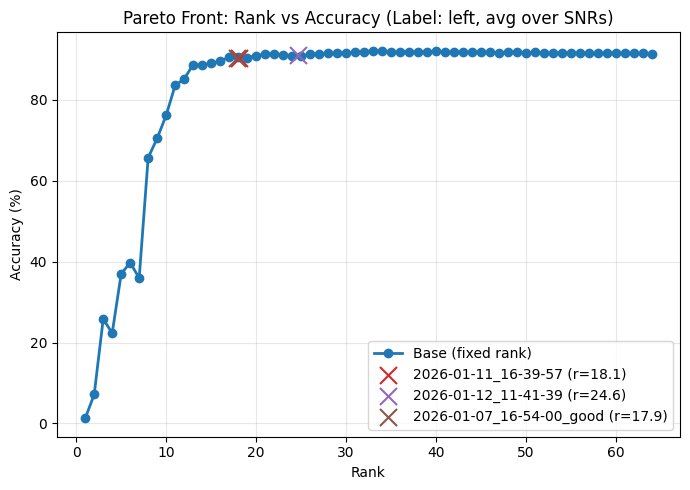


Label: no (target=3)

  2026-01-11_16-39-57: rank=18.22, acc=90.74%
  2026-01-12_11-41-39: rank=25.02, acc=90.74%
  2026-01-07_16-54-00_good: rank=17.99, acc=90.67%
  Base @ rank=18: acc=90.83%
  Base @ rank=19: acc=90.97%
  2026-01-11_16-39-57: rank=18.22, acc=90.74%
  2026-01-12_11-41-39: rank=25.02, acc=90.74%
  2026-01-07_16-54-00_good: rank=17.99, acc=90.67%
  Base @ rank=18: acc=90.83%
  Base @ rank=19: acc=90.97%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


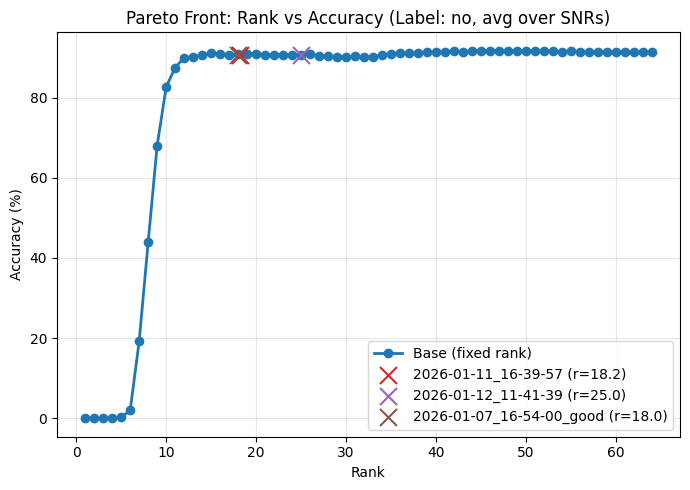


Label: off (target=4)
  2026-01-11_16-39-57: rank=18.37, acc=86.78%
  2026-01-12_11-41-39: rank=25.02, acc=86.13%
  2026-01-07_16-54-00_good: rank=18.04, acc=84.94%
  Base @ rank=18: acc=86.10%
  Base @ rank=19: acc=86.45%
  2026-01-11_16-39-57: rank=18.37, acc=86.78%
  2026-01-12_11-41-39: rank=25.02, acc=86.13%
  2026-01-07_16-54-00_good: rank=18.04, acc=84.94%
  Base @ rank=18: acc=86.10%
  Base @ rank=19: acc=86.45%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


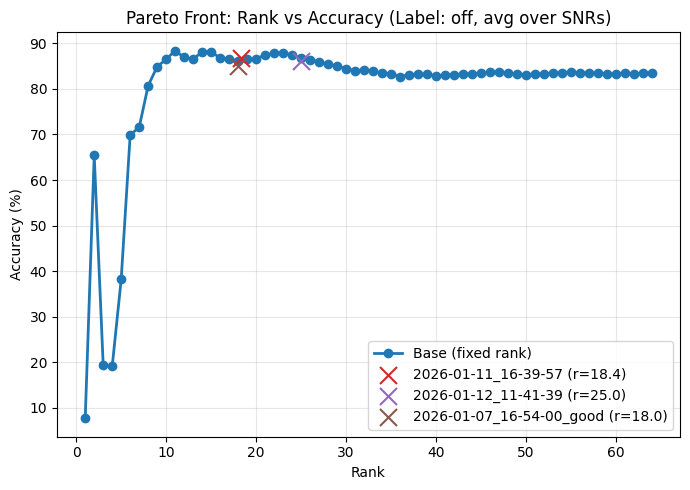


Label: on (target=5)
  2026-01-11_16-39-57: rank=18.25, acc=91.37%
  2026-01-12_11-41-39: rank=25.02, acc=91.81%
  2026-01-07_16-54-00_good: rank=17.97, acc=92.87%
  Base @ rank=18: acc=91.57%
  Base @ rank=19: acc=91.39%
  2026-01-11_16-39-57: rank=18.25, acc=91.37%
  2026-01-12_11-41-39: rank=25.02, acc=91.81%
  2026-01-07_16-54-00_good: rank=17.97, acc=92.87%
  Base @ rank=18: acc=91.57%
  Base @ rank=19: acc=91.39%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


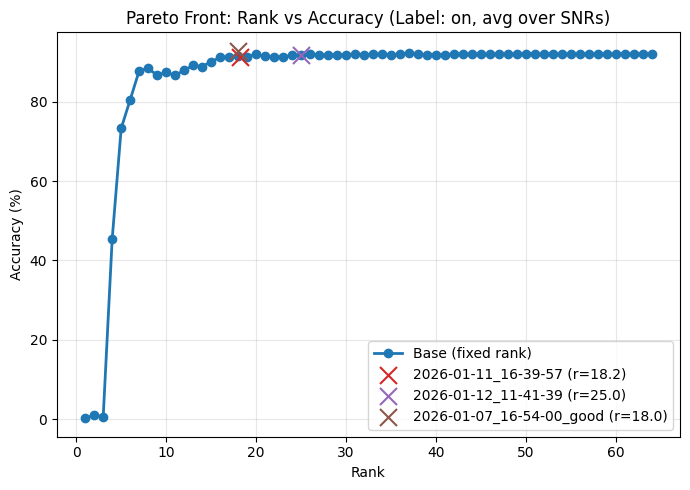


Label: right (target=6)
  2026-01-11_16-39-57: rank=18.37, acc=79.44%
  2026-01-12_11-41-39: rank=25.09, acc=85.36%
  2026-01-07_16-54-00_good: rank=18.14, acc=84.74%
  Base @ rank=18: acc=79.19%
  Base @ rank=19: acc=81.31%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


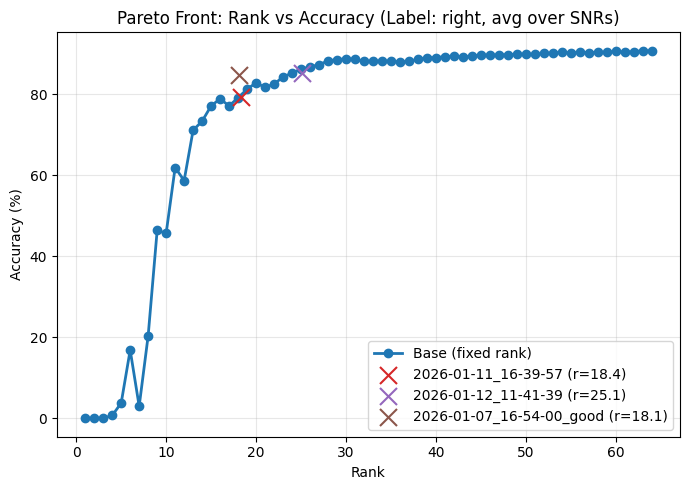


Label: stop (target=7)
  2026-01-11_16-39-57: rank=18.13, acc=87.36%
  2026-01-12_11-41-39: rank=24.86, acc=89.95%
  2026-01-07_16-54-00_good: rank=17.94, acc=86.01%
  Base @ rank=18: acc=87.93%
  Base @ rank=19: acc=88.78%

  2026-01-11_16-39-57: rank=18.13, acc=87.36%
  2026-01-12_11-41-39: rank=24.86, acc=89.95%
  2026-01-07_16-54-00_good: rank=17.94, acc=86.01%
  Base @ rank=18: acc=87.93%
  Base @ rank=19: acc=88.78%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


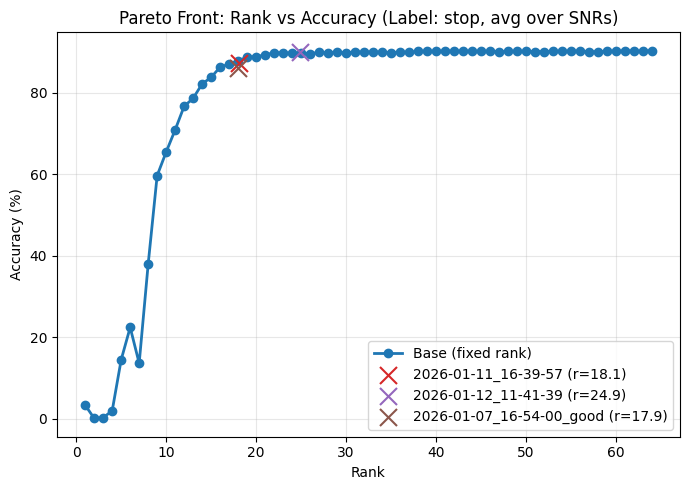


Label: up (target=8)


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


  2026-01-11_16-39-57: rank=18.01, acc=85.40%
  2026-01-12_11-41-39: rank=24.56, acc=86.64%
  2026-01-07_16-54-00_good: rank=17.78, acc=82.68%
  Base @ rank=18: acc=85.67%
  Base @ rank=19: acc=84.94%


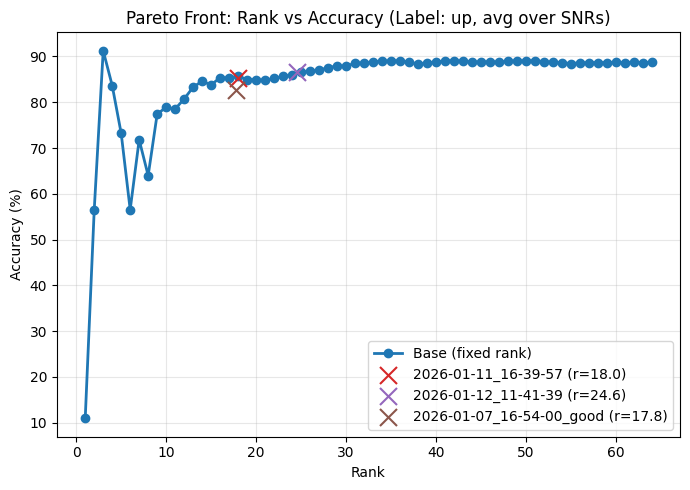


Label: yes (target=9)
  2026-01-11_16-39-57: rank=18.54, acc=92.54%
  2026-01-12_11-41-39: rank=25.08, acc=94.86%
  2026-01-07_16-54-00_good: rank=18.06, acc=94.26%
  Base @ rank=19: acc=93.49%
  Base @ rank=18: acc=93.19%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


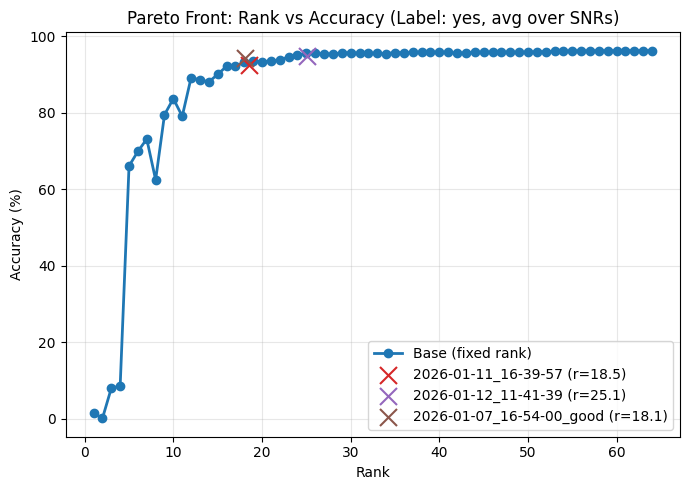


Label: UNKNOWN (target=10)
  2026-01-11_16-39-57: rank=18.33, acc=66.67%
  2026-01-12_11-41-39: rank=24.99, acc=71.54%
  2026-01-07_16-54-00_good: rank=18.04, acc=68.73%
  Base @ rank=18: acc=68.52%
  Base @ rank=19: acc=68.39%

  2026-01-11_16-39-57: rank=18.33, acc=66.67%
  2026-01-12_11-41-39: rank=24.99, acc=71.54%
  2026-01-07_16-54-00_good: rank=18.04, acc=68.73%
  Base @ rank=18: acc=68.52%
  Base @ rank=19: acc=68.39%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


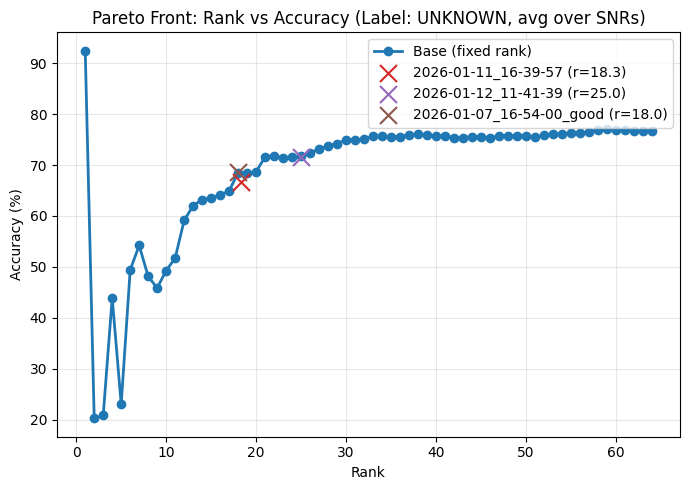


Label: SILENCE (target=11)
  2026-01-11_16-39-57: rank=21.14, acc=97.09%
  2026-01-12_11-41-39: rank=30.24, acc=87.60%
  2026-01-07_16-54-00_good: rank=19.60, acc=94.13%
  Base @ rank=21: acc=80.05%
  Base @ rank=22: acc=78.08%
  2026-01-11_16-39-57: rank=21.14, acc=97.09%
  2026-01-12_11-41-39: rank=30.24, acc=87.60%
  2026-01-07_16-54-00_good: rank=19.60, acc=94.13%
  Base @ rank=21: acc=80.05%
  Base @ rank=22: acc=78.08%


/var/folders/34/g_c3hj2n7d5_m2hrl1tm7wj80000gn/T/ipykernel_9825/2968661702.py:86: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


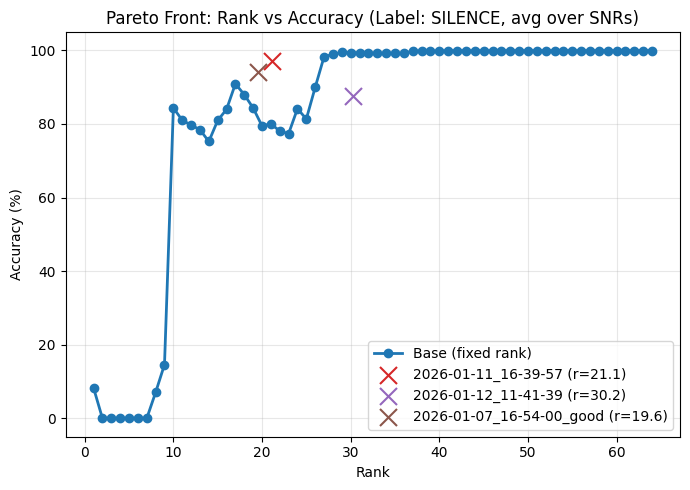

In [11]:
def plot_pareto_front_per_label(
    df_base: pd.DataFrame,
    df_dyn: pd.DataFrame,
    *,
    label_col: str = "label",
    rank_col: str = "rank",
    correct_col: str = "correct",
    target_col: str = "target",
    model_name_col: str = "model_name",
    figsize: tuple = (7, 5),
    marker_base: str = "o-",
    marker_dyn: str = "x",
    color_base: str = "C0",
    dyn_colors: list = None,
):
    """
    Plot Pareto fronts: rank vs accuracy for each label (averaged over all SNR values).
    
    Base model: shown as a curve with multiple rank points (averaged over noise files and SNRs)
    Dynamic models: shown as points (mean rank, mean accuracy) - supports multiple models
    
    Args:
        df_base: DataFrame with base model results (fixed ranks)
        df_dyn: DataFrame with dynamic model results (continuous ranks), can contain multiple models
        label_col: Column name for the label field
        dyn_colors: List of colors for dynamic models. If None, uses default color cycle.
    """
    
    if dyn_colors is None:
        dyn_colors = ['C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']
    
    # Get unique target classes (integers)
    target_classes = sorted(df_base[target_col].unique())
    
    # Get unique dynamic model names
    dyn_model_names = df_dyn[model_name_col].unique()
    
    for target_class in target_classes:
        # --- BASE MODEL: aggregate over noise files and SNRs for each rank ---
        # Filter for samples where target == target_class
        base_label = df_base[df_base[target_col] == target_class]
        
        if len(base_label) == 0:
            continue
            
        base_agg = (
            base_label.groupby(rank_col)[correct_col]
            .mean()
            .mul(100)
            .reset_index()
            .rename(columns={correct_col: "acc"})
            .sort_values(rank_col)
        )
        
        # --- PLOT ---
        plt.figure(figsize=figsize)
        
        # Base model curve
        plt.plot(
            base_agg[rank_col],
            base_agg["acc"],
            marker_base,
            label="Base (fixed rank)",
            color=color_base,
            linewidth=2,
            markersize=6,
        )
        
        # --- DYNAMIC MODELS: one point per model ---
        # Get the label name for this target class (for display)
        label_name = base_label[label_col].iloc[0] if len(base_label) > 0 else f"Class {target_class}"
        print(f"\nLabel: {label_name} (target={target_class})")
        
        for idx, model_name in enumerate(dyn_model_names):
            # Filter for samples where target == target_class
            dyn_label = df_dyn[(df_dyn[target_col] == target_class) & (df_dyn[model_name_col] == model_name)]
            
            if len(dyn_label) == 0:
                continue
                
            dyn_mean_rank = dyn_label[rank_col].mean()
            dyn_mean_acc = dyn_label[correct_col].mean() * 100
            
            color = dyn_colors[idx % len(dyn_colors)]
            
            plt.scatter(
                [dyn_mean_rank],
                [dyn_mean_acc],
                s=150,
                marker=marker_dyn,
                color=color,
                label=f"{model_name} (r={dyn_mean_rank:.1f})",
                edgecolors="black",
                linewidths=1.5,
                zorder=5,
            )
            
            print(f"  {model_name}: rank={dyn_mean_rank:.2f}, acc={dyn_mean_acc:.2f}%")
        
        # Find the two closest base model ranks to first dynamic model
        if len(dyn_model_names) > 0:
            first_dyn_label = df_dyn[(df_dyn[target_col] == target_class) & (df_dyn[model_name_col] == dyn_model_names[0])]
            if len(first_dyn_label) > 0:
                first_dyn_rank = first_dyn_label[rank_col].mean()
                
                base_agg['rank_diff'] = abs(base_agg[rank_col] - first_dyn_rank)
                closest_two = base_agg.nsmallest(2, 'rank_diff')
                
                for _, row in closest_two.iterrows():
                    print(f"  Base @ rank={int(row[rank_col])}: acc={row['acc']:.2f}%")
        
        plt.xlabel("Rank")
        plt.ylabel("Accuracy (%)")
        plt.title(f"Pareto Front: Rank vs Accuracy (Label: {label_name}, avg over SNRs)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# Call the function
if df_dyn_combined is not None:
    plot_pareto_front_per_label(df_base, df_dyn_combined)